<a href="https://colab.research.google.com/github/anitabudhiraja/DeepLearning/blob/main/practical_11_cpu_vs_gpu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning Techniques (DOAI250006)
## Institution: NIELIT ROPAR
## Practical 11: Implementation of deep CNN for multiclass image classification and comparison of CPU-vs-GPU training performance

This notebook builds a deep Convolutional Neural Network (CNN) to classify images from the CIFAR-10 dataset. Its primary goal is to demonstrate the performance difference when training the exact same model on a Central Processing Unit (CPU) versus a Graphics Processing Unit (GPU).

**Note:** Google Colab (make sure to enable the GPU T4 runtime in Colab!).

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import time

print("TensorFlow version:", tf.__version__)

# Check for available GPUs
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU(s) detected: {[gpu.name for gpu in gpus]}")
else:
    print("WARNING: No GPU detected. The GPU training section will not run optimally.")
    print("If you are on Google Colab, go to Runtime > Change runtime type > Hardware accelerator > T4 GPU.")

TensorFlow version: 2.20.0
GPU(s) detected: ['/physical_device:GPU:0']


### 1. Data Loading and Preprocessing
We use the CIFAR-10 dataset (60,000 32x32 color images in 10 classes). We normalize the pixel values to accelerate convergence.

In [ ]:
# Load dataset
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

print(f'Training images shape: {train_images.shape}')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Training images shape: (50000, 32, 32, 3)


### 2. Model Builder Function
To ensure a fair comparison, we need the exact same model architecture initialized from scratch for both the CPU and GPU training runs. We define a function that returns a fresh compiled model.

In [ ]:
def build_deep_cnn():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Display architecture once
dummy_model = build_deep_cnn()
dummy_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,168,746 (8.27 MB)

 Trainable params: 2,168,554 (8.27 MB)

 Non-trainable params: 192 (768.00 B)

### 3. CPU Training Performance
We use the `tf.device('/CPU:0')` context manager to force TensorFlow to execute the training loop entirely on the processor. We will only train for 3 epochs to save time, as CPU training is typically very slow.

In [ ]:
EPOCHS = 3
BATCH_SIZE = 64

print("Starting CPU Training")

# Record start time
start_time_cpu = time.time()

# Force execution AND model initialization on CPU
with tf.device('/CPU:0'):
    model_cpu = build_deep_cnn() # Moved inside the context manager!
    history_cpu = model_cpu.fit(train_images, train_labels,
                                epochs=EPOCHS,
                                batch_size=BATCH_SIZE,
                                validation_split=0.1,
                                verbose=1)

# Calculate elapsed time
cpu_time = time.time() - start_time_cpu
print(f"\n>>> CPU Training completed in: {cpu_time:.2f} seconds <<<")

Starting CPU Training
Epoch 1/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 249s 345ms/step - accuracy: 0.3671 - loss: 1.7763 - val_accuracy: 0.4942 - val_loss: 1.3547
Epoch 2/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 235s 334ms/step - accuracy: 0.5129 - loss: 1.3473 - val_accuracy: 0.6048 - val_loss: 1.1128
Epoch 3/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 266s 340ms/step - accuracy: 0.5904 - loss: 1.1573 - val_accuracy: 0.6770 - val_loss: 0.9554

>>> CPU Training completed in: 751.05 seconds <<<


### 4. GPU Training Performance
Now we force the execution onto the GPU using `tf.device('/GPU:0')`. GPUs are optimized for parallel matrix operations, which makes them uniquely suited for training deep CNNs.

In [ ]:
gpu_time = 0 # Initialize variable

if gpus:
    print("\n--- Starting GPU Training ---")
    model_gpu = build_deep_cnn()

    # Record start time
    start_time_gpu = time.time()

    # Force execution on GPU
    with tf.device('/GPU:0'):
        history_gpu = model_gpu.fit(train_images, train_labels,
                                    epochs=EPOCHS,
                                    batch_size=BATCH_SIZE,
                                    validation_split=0.1,
                                    verbose=1)

    # Calculate elapsed time
    gpu_time = time.time() - start_time_gpu
    print(f"\n>>> GPU Training completed in: {gpu_time:.2f} seconds <<<")
else:
    print("\nNo GPU available to run the comparison.")


--- Starting GPU Training ---
Epoch 1/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - accuracy: 0.3596 - loss: 1.7802 - val_accuracy: 0.5380 - val_loss: 1.3048
Epoch 2/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5123 - loss: 1.3510 - val_accuracy: 0.6310 - val_loss: 1.0451
Epoch 3/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5869 - loss: 1.1590 - val_accuracy: 0.6598 - val_loss: 0.9651

>>> GPU Training completed in: 34.12 seconds <<<


### 5. CPU vs GPU Performance Comparison
We visualize the time difference using a bar chart and calculate the speedup multiplier.


Result: The GPU was 22.02x faster than the CPU!


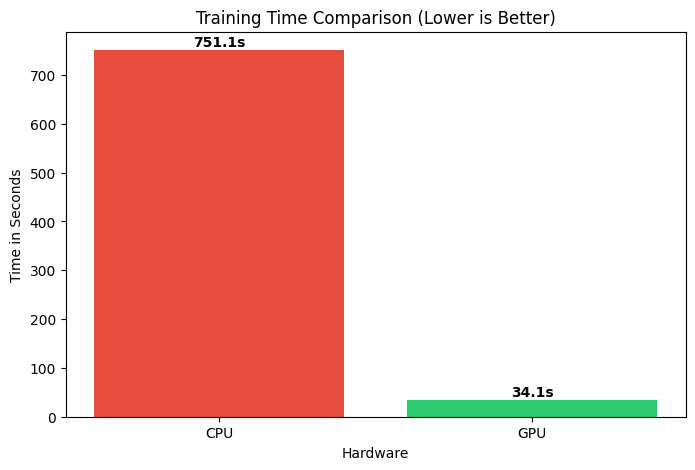

In [ ]:
if gpus and gpu_time > 0:
    # Calculate speedup
    speedup = cpu_time / gpu_time
    print(f"\nResult: The GPU was {speedup:.2f}x faster than the CPU!")

    # Plotting
    devices = ['CPU', 'GPU']
    times = [cpu_time, gpu_time]

    plt.figure(figsize=(8, 5))
    bars = plt.bar(devices, times, color=['#e74c3c', '#2ecc71'])
    plt.title('Training Time Comparison (Lower is Better)')
    plt.ylabel('Time in Seconds')
    plt.xlabel('Hardware')

    # Add text labels above bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}s', ha='center', va='bottom', fontweight='bold')

    plt.show()
else:
    print("Comparison plot cannot be generated because GPU training was skipped.")